In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)

import matplotlib.pyplot as plt

In [28]:
reviews = pd.read_csv(
    "../data/raw/reviews.csv"
)

print("Raw dataset shape:", reviews.shape)

reviews.head()

Raw dataset shape: (12495, 12)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo


In [29]:
required_columns = {
    "content",
    "score",
}

missing_columns = (
    required_columns
    - set(reviews.columns)
)

assert not missing_columns, (
    f"Missing required columns: {missing_columns}"
)

print("Required columns are present.")

Required columns are present.


In [30]:
reviews_clean = reviews.dropna(
    subset=[
        "content",
        "score",
    ]
).copy()

reviews_clean = reviews_clean[
    reviews_clean["content"]
    .astype(str)
    .str.strip()
    .ne("")
].copy()

print(
    "Rows before cleaning:",
    len(reviews)
)

print(
    "Rows after invalid-row removal:",
    len(reviews_clean)
)

print(
    "Rows removed:",
    len(reviews)
    - len(reviews_clean)
)

Rows before cleaning: 12495
Rows after invalid-row removal: 12495
Rows removed: 0


In [31]:
valid_scores = {
    1,
    2,
    3,
    4,
    5,
}

assert set(
    reviews_clean["score"].unique()
).issubset(
    valid_scores
)

print("Score validation passed.")

Score validation passed.


In [32]:
def score_to_sentiment(score):
    if score <= 2:
        return "negative"

    if score == 3:
        return "neutral"

    return "positive"


reviews_clean["sentiment"] = (
    reviews_clean["score"]
    .apply(score_to_sentiment)
)

print(
    reviews_clean["sentiment"]
    .value_counts()
)

sentiment
positive    5654
negative    4850
neutral     1991
Name: count, dtype: int64


In [33]:
reviews_clean["normalised"] = (
    reviews_clean["content"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(
        r"\s+",
        " ",
        regex=True,
    )
)

In [34]:
label_counts_per_text = (
    reviews_clean
    .groupby("normalised")[
        "sentiment"
    ]
    .nunique()
)

conflicting_texts = (
    label_counts_per_text[
        label_counts_per_text > 1
    ]
    .index
)

model_reviews = reviews_clean[
    ~reviews_clean[
        "normalised"
    ].isin(
        conflicting_texts
    )
].copy()

print(
    "Conflicting text groups removed:",
    len(conflicting_texts)
)

Conflicting text groups removed: 53


In [35]:
model_reviews = (
    model_reviews
    .drop_duplicates(
        subset=[
            "normalised",
            "sentiment",
        ]
    )
    .copy()
)

print(
    "Final cleaned rows:",
    len(model_reviews)
)

print()

print(
    model_reviews[
        "sentiment"
    ].value_counts()
)

Final cleaned rows: 11684

sentiment
positive    5064
negative    4734
neutral     1886
Name: count, dtype: int64


In [36]:
def show_distribution(name, labels):
    counts = labels.value_counts()
    proportions = labels.value_counts(
        normalize=True
    ).round(4)

    result = pd.DataFrame({
        "count": counts,
        "proportion": proportions,
    })

    print(f"\n{name}")
    print(result)


show_distribution(
    "TRAIN",
    y_train,
)

show_distribution(
    "VALIDATION",
    y_validation,
)

show_distribution(
    "TEST",
    y_test,
)


TRAIN
           count  proportion
sentiment                   
positive    3544      0.4334
negative    3314      0.4052
neutral     1320      0.1614

VALIDATION
           count  proportion
sentiment                   
positive     760      0.4335
negative     710      0.4050
neutral      283      0.1614

TEST
           count  proportion
sentiment                   
positive     760      0.4335
negative     710      0.4050
neutral      283      0.1614


In [37]:
train_texts = set(X_train)
validation_texts = set(X_validation)
test_texts = set(X_test)

assert train_texts.isdisjoint(
    validation_texts
)

assert train_texts.isdisjoint(
    test_texts
)

assert validation_texts.isdisjoint(
    test_texts
)

assert (
    len(X_train)
    + len(X_validation)
    + len(X_test)
    == len(model_reviews)
)

print(
    "Train/validation/test overlap checks passed."
)

Train/validation/test overlap checks passed.


In [38]:
tfidf_unigram = TfidfVectorizer()

X_train_tfidf_unigram = tfidf_unigram.fit_transform(
    X_train
)

X_validation_tfidf_unigram = tfidf_unigram.transform(
    X_validation
)

print(
    "Unigram train shape:",
    X_train_tfidf_unigram.shape
)

print(
    "Unigram validation shape:",
    X_validation_tfidf_unigram.shape
)

Unigram train shape: (8178, 10282)
Unigram validation shape: (1753, 10282)


In [39]:
tfidf_unigram_bigram = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_tfidf_bigram = (
    tfidf_unigram_bigram.fit_transform(
        X_train
    )
)

X_validation_tfidf_bigram = (
    tfidf_unigram_bigram.transform(
        X_validation
    )
)

print(
    "Unigram + bigram train shape:",
    X_train_tfidf_bigram.shape
)

print(
    "Unigram + bigram validation shape:",
    X_validation_tfidf_bigram.shape
)

Unigram + bigram train shape: (8178, 26513)
Unigram + bigram validation shape: (1753, 26513)


In [40]:
assert (
    X_train_tfidf_unigram.shape[1]
    == X_validation_tfidf_unigram.shape[1]
)

assert (
    X_train_tfidf_bigram.shape[1]
    == X_validation_tfidf_bigram.shape[1]
)

print("TF-IDF validation checks passed.")

TF-IDF validation checks passed.


In [41]:
LABELS = [
    "negative",
    "neutral",
    "positive",
]


def evaluate_model(
    y_true,
    predictions,
):
    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_true,
            predictions,
            labels=LABELS,
            zero_division=0,
        )
    )

    macro_f1 = (
        precision_recall_fscore_support(
            y_true,
            predictions,
            average="macro",
            zero_division=0,
        )[2]
    )

    weighted_f1 = (
        precision_recall_fscore_support(
            y_true,
            predictions,
            average="weighted",
            zero_division=0,
        )[2]
    )

    return {
        "accuracy": float(
            accuracy_score(
                y_true,
                predictions,
            )
        ),
        "macro_f1": float(
            macro_f1
        ),
        "weighted_f1": float(
            weighted_f1
        ),
        "negative_f1": float(
            f1[0]
        ),
        "neutral_f1": float(
            f1[1]
        ),
        "positive_f1": float(
            f1[2]
        ),
    }

In [42]:
# ---------------------------------------------------------
# Candidate 1: Unweighted Logistic Regression — Unigrams
# ---------------------------------------------------------

unweighted_logreg = LogisticRegression(
    max_iter=1000,
    class_weight=None,
    random_state=42,
)

unweighted_logreg.fit(
    X_train_tfidf_unigram,
    y_train,
)

unweighted_logreg_predictions = (
    unweighted_logreg.predict(
        X_validation_tfidf_unigram
    )
)

unweighted_logreg_metrics = evaluate_model(
    y_validation,
    unweighted_logreg_predictions,
)


# ---------------------------------------------------------
# Candidate 2: Balanced Logistic Regression — Unigrams
# ---------------------------------------------------------

balanced_logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
)

balanced_logreg.fit(
    X_train_tfidf_unigram,
    y_train,
)

balanced_logreg_predictions = (
    balanced_logreg.predict(
        X_validation_tfidf_unigram
    )
)

balanced_logreg_metrics = evaluate_model(
    y_validation,
    balanced_logreg_predictions,
)


# ---------------------------------------------------------
# Candidate 3: Balanced Linear SVM — Unigrams
# ---------------------------------------------------------

balanced_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42,
)

balanced_svm.fit(
    X_train_tfidf_unigram,
    y_train,
)

balanced_svm_predictions = (
    balanced_svm.predict(
        X_validation_tfidf_unigram
    )
)

balanced_svm_metrics = evaluate_model(
    y_validation,
    balanced_svm_predictions,
)


# ---------------------------------------------------------
# Candidate 4: Balanced Logistic Regression
# Unigrams + Bigrams
# ---------------------------------------------------------

balanced_logreg_bigram = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
)

balanced_logreg_bigram.fit(
    X_train_tfidf_bigram,
    y_train,
)

balanced_logreg_bigram_predictions = (
    balanced_logreg_bigram.predict(
        X_validation_tfidf_bigram
    )
)

balanced_logreg_bigram_metrics = evaluate_model(
    y_validation,
    balanced_logreg_bigram_predictions,
)


# ---------------------------------------------------------
# Compare validation results
# ---------------------------------------------------------

validation_results = pd.DataFrame([
    {
        "model": "LogReg Unweighted — Unigram",
        **unweighted_logreg_metrics,
    },
    {
        "model": "LogReg Balanced — Unigram",
        **balanced_logreg_metrics,
    },
    {
        "model": "Linear SVM Balanced — Unigram",
        **balanced_svm_metrics,
    },
    {
        "model": "LogReg Balanced — Unigram + Bigram",
        **balanced_logreg_bigram_metrics,
    },
])

validation_results = validation_results.sort_values(
    by="macro_f1",
    ascending=False,
).reset_index(drop=True)

validation_results.round(4)

,model,accuracy,macro_f1,weighted_f1,negative_f1,neutral_f1,positive_f1
0,LogReg Balanced — Unigram + Bigram,0.7028,0.6317,0.7087,0.7455,0.3366,0.8129
1,LogReg Balanced — Unigram,0.6823,0.6181,0.6945,0.7286,0.3258,0.8000
2,Linear SVM Balanced — Unigram,0.6897,0.5926,0.6816,0.7348,0.2505,0.7925
3,LogReg Unweighted — Unigram,0.7359,0.5816,0.6952,0.7779,0.1437,0.8232


In [43]:
# ---------------------------------------------------------
# Final evaluation on untouched test set
# ---------------------------------------------------------

X_test_tfidf_bigram = (
    tfidf_unigram_bigram.transform(
        X_test
    )
)

final_test_predictions = (
    balanced_logreg_bigram.predict(
        X_test_tfidf_bigram
    )
)

final_test_metrics = evaluate_model(
    y_test,
    final_test_predictions,
)

print("FINAL TEST METRICS")
print(final_test_metrics)

FINAL TEST METRICS
{'accuracy': 0.7027952082144895, 'macro_f1': 0.6362974423673158, 'weighted_f1': 0.7087544931600136, 'negative_f1': 0.7424135497529993, 'neutral_f1': 0.35889070146818924, 'positive_f1': 0.8075880758807588}


In [44]:
print(
    classification_report(
        y_test,
        final_test_predictions,
        labels=LABELS,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

    negative     0.7440    0.7408    0.7424       710
     neutral     0.3333    0.3887    0.3589       283
    positive     0.8324    0.7842    0.8076       760

    accuracy                         0.7028      1753
   macro avg     0.6366    0.6379    0.6363      1753
weighted avg     0.7160    0.7028    0.7088      1753



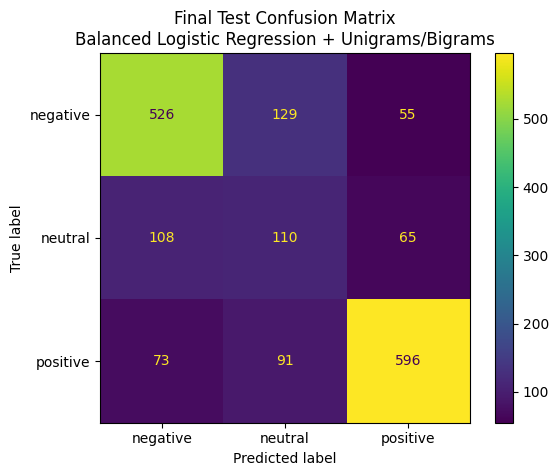

In [45]:
final_confusion_matrix = confusion_matrix(
    y_test,
    final_test_predictions,
    labels=LABELS,
)

final_confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=LABELS,
)

final_confusion_display.plot()
plt.title(
    "Final Test Confusion Matrix\n"
    "Balanced Logistic Regression + Unigrams/Bigrams"
)
plt.show()

In [46]:
test_analysis = pd.DataFrame({
    "review": X_test.values,
    "actual": y_test.values,
    "predicted": final_test_predictions,
})

test_analysis["correct"] = (
    test_analysis["actual"]
    == test_analysis["predicted"]
)

print("Correct predictions:")
print(test_analysis["correct"].value_counts())

print(
    "\nOverall error rate:",
    round(
        1 - test_analysis["correct"].mean(),
        4,
    ),
)

Correct predictions:
correct
True     1232
False     521
Name: count, dtype: int64

Overall error rate: 0.2972


In [47]:
errors = test_analysis[
    ~test_analysis["correct"]
].copy()

error_types = (
    errors
    .groupby(
        [
            "actual",
            "predicted",
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False,
    )
)

error_types

,actual,predicted,count
0,negative,neutral,129
2,neutral,negative,108
5,positive,neutral,91
4,positive,negative,73
3,neutral,positive,65
1,negative,positive,55


In [48]:
neutral_errors = errors[
    errors["actual"] == "neutral"
]

neutral_errors.sample(
    min(
        20,
        len(neutral_errors),
    ),
    random_state=42,
)[
    [
        "review",
        "actual",
        "predicted",
    ]
]

,review,actual,predicted
1663,"good experience, nice concept, sad that it's n...",neutral,negative
393,great app👌🏿👌🏿👌🏿,neutral,positive
973,i believe i am rating about getting back on en...,neutral,negative
625,hi! the range of the nuce coloured sectors doe...,neutral,negative
1172,could be a great app except that like another ...,neutral,negative
1408,i like it but when i put my pass code in to ac...,neutral,negative
384,wunderlist was waaay better. too bad that one ...,neutral,negative
142,"i like that this app notifies you for tasks, b...",neutral,negative
1166,i've just installed this app and will definite...,neutral,positive
1115,the app is great except for being internet dep...,neutral,negative


In [49]:
X_train_final = pd.concat(
    [
        X_train,
        X_validation,
    ]
)

y_train_final = pd.concat(
    [
        y_train,
        y_validation,
    ]
)

print(
    "Final production training rows:",
    len(X_train_final)
)

print(
    y_train_final.value_counts()
)

Final production training rows: 9931
sentiment
positive    4304
negative    4024
neutral     1603
Name: count, dtype: int64


In [50]:
from sklearn.pipeline import Pipeline


final_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        ),
    ),
])

In [51]:
final_pipeline.fit(
    X_train_final,
    y_train_final,
)

print(
    "Final production pipeline trained."
)

Final production pipeline trained.


In [52]:
from pathlib import Path
import joblib

pipeline_path = Path(
    "/Users/krrishmujoo/Desktop/sentiment analyser project/models/final_sentiment_pipeline.joblib"
)

joblib.dump(
    final_pipeline,
    pipeline_path,
)

print("Saved to:", pipeline_path)
print("Exists:", pipeline_path.exists())
print("Size:", pipeline_path.stat().st_size, "bytes")

Saved to: /Users/krrishmujoo/Desktop/sentiment analyser project/models/final_sentiment_pipeline.joblib
Exists: True
Size: 1476452 bytes
